# Bogus Basin Snow Depth

In [2]:


import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import os
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pathlib import Path
import sys
#from data_registry import datasets
from scipy.ndimage import uniform_filter1d
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scipy.stats as stats
from scipy.interpolate import interp1d

from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.gam.api import GLMGam
from statsmodels.gam.api import BSplines
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings("ignore")
# os.getcwd()
# os.chdir(r"C:\Users\ryanc\repo\Time-Series-Analysis-Project")
    

c:\Users\ryanc\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


*Utility functions*


In [3]:
perf_results = []

def evaluate_performance(true, pred, model_name="Model"):
    mspe = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    mape = np.mean(np.abs((true - pred) / (true + 1e-6)))
    pm = (np.sum((true- pred) ** 2) / np.sum((true- np.mean(true)) ** 2))

    print(f"=== {model_name} Performance ===")
    print(f"MSPE: {mspe:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"PM:   {pm:.4f}")
    print("-" * 40)
    perf_results.append({'model': model_name, 'MSPE': mspe, 'MAE':mae, 'MAPE': mape, 'PM': pm})

def to_ts(data, dates=None):
    data = data.copy()
    aDict = {'ts': np.array(data)}
    aRange = np.arange(len(data))
    aDict['pts'] = (aRange - np.min(aRange)) / np.max(aRange)
    if dates is not None:
        indexDates = pd.to_datetime(dates, errors='coerce')
    elif isinstance(data, pd.Series) and isinstance(data.index, pd.DatetimeIndex):
        indexDates = data.index
    else:
        indexDates = aRange
    return pd.DataFrame(aDict, index=indexDates).dropna()



## Plot and Exploratory Analysis

*Read data*

In [4]:

snow_data = pd.read_csv('BogusSnowDaily.csv')
snow_data.columns = (['Date', 'Depth'])

snow_data['Date'] = pd.to_datetime(snow_data['Date'])
snow_data.set_index('Date',drop=True, inplace=True)

snow_daily = to_ts(snow_data['Depth'], snow_data.index)


In [5]:
snow_daily['ts'].describe()

count    9411.000000
mean       23.031771
std        27.478365
min         0.000000
25%         0.000000
50%         6.000000
75%        48.000000
max       113.000000
Name: ts, dtype: float64

Text(0.5, 1.0, 'Snow depth distribution')

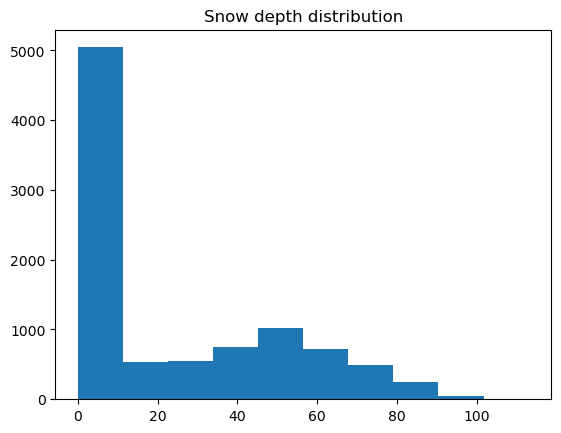

In [6]:


plt.hist(snow_daily['ts'])
plt.title("Snow depth distribution")

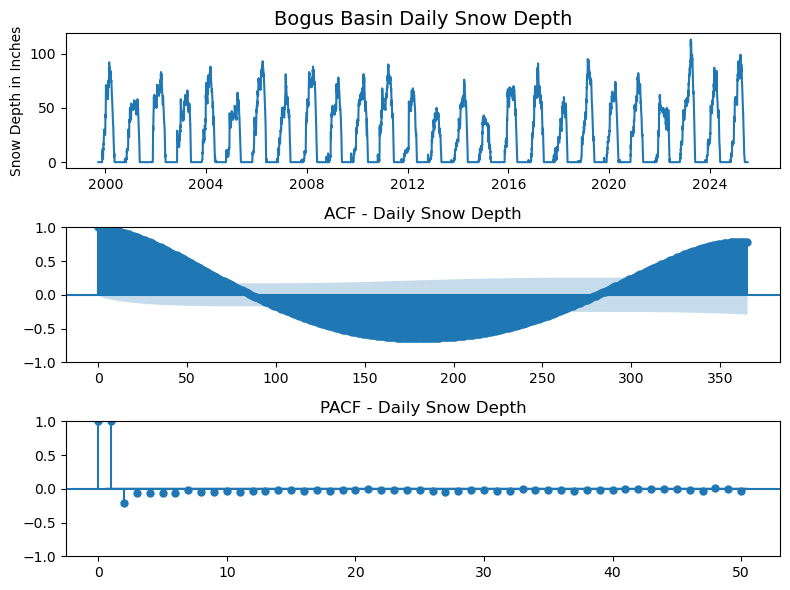

In [7]:
fig, axs = plt.subplots(3,1 ,figsize=(8,6))
axs[0].plot(snow_daily['ts'])
axs[0].set_title('Bogus Basin Daily Snow Depth', size = 14)
axs[0].set_ylabel("Snow Depth in Inches")
plot_acf(snow_daily['ts'], lags = 365, ax = axs[1], title = 'ACF - Daily Snow Depth');
plot_pacf(snow_daily['ts'], lags = 50, ax = axs[2], title = "PACF - Daily Snow Depth");

# axs[1].plot(snow_monthly['ts'], marker = '.', markersize = 5  )
# axs[1].set_title('Bogus Basin Monthly Average Snow Depth')
# axs[1].set_ylabel("Snow Depth in Inches")
fig.tight_layout()
fig.show()

The daily snow data exhibits a strong seasonal pattern with no clear discernable trend. A key feature of this data is the large periods of time with zero values during the warmer months.  While one approach could be to remove all the zero values, they are a key data point, as forecasting when snow begins and ends is a key part of this analysis.  Close attention will be paid to how successful the models are in capturing these zero points. 

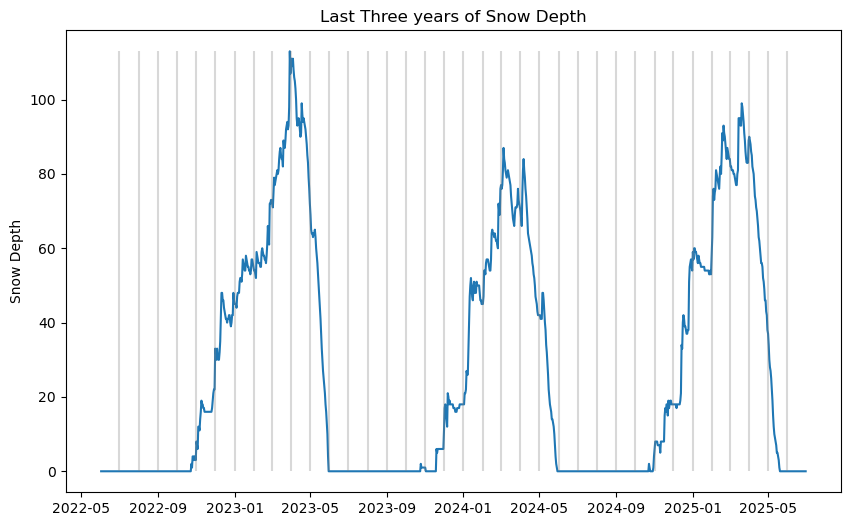

In [8]:
last_3_years = snow_daily[snow_daily.index > '2022-06-01']
loc = mdates.MonthLocator(bymonthday=1)
month_starts = loc.tick_values(last_3_years.index.min(), last_3_years.index.max())

plt.figure(figsize=(10,6))
plt.plot(last_3_years['ts'])
plt.vlines(month_starts, 0,last_3_years['ts'].max(), alpha = .3, color = 'grey')
plt.title("Last Three years of Snow Depth")
plt.ylabel("Snow Depth")
plt.show()


Focusing in on the last three years of snow data shows interesting patterns in each year.  The warmer months have a snow depth of 0, typically from June to October or November.  Snow depth is dictated by snow storms, which lead to a sharp increase in snow depth.  The sharp increase is followed by a period of no increase or slight decrease, as snow melts. The peak of snow depth is reached around April each year, when warming temperatures lead to melting snow and a sharp decrease in snow levels.  

Splitting data into training and testing data sets, with testing set for the last year's worth of data. Adding in categorical variables at month, week, and day levels for seasonal analysis 

In [9]:
cutoff_date = '06/01/2024'

sd= snow_daily.copy()
sd['ts'] = sd['ts']+1
sd['month'] = sd.index.month
sd['week'] = sd.index.isocalendar().week.astype('int')
sd['day'] = sd.index.dayofyear

sd_train = sd[sd.index<cutoff_date]
sd_test = sd[sd.index>=cutoff_date]

print(sd_train.tail())
print(sd_test.head())


            ts       pts  month  week  day
Date                                      
2024-05-27   5  0.957598      5    22  148
2024-05-28   3  0.957705      5    22  149
2024-05-29   2  0.957811      5    22  150
2024-05-30   1  0.957917      5    22  151
2024-05-31   1  0.958023      5    22  152
            ts       pts  month  week  day
Date                                      
2024-06-01   1  0.958130      6    22  153
2024-06-02   1  0.958236      6    22  154
2024-06-03   1  0.958342      6    23  155
2024-06-04   1  0.958448      6    23  156
2024-06-05   1  0.958555      6    23  157


# Decomposition Modeling



## Trend Estimation Using Moving Average, Local Polynomial, and Splines

In [10]:
#Moving Average Trend
mavModel = uniform_filter1d(sd_train['ts'], size=len(sd_train['ts'])//2)
mavModel
mav_data = pd.Series(mavModel, index=sd_train.index)


#Lowess Trend
localPolyModel = sm.nonparametric.lowess(endog=sd_train['ts'], exog=sd_train['pts'], is_sorted=True, frac=0.5)

## extrapolate local polynomial and Moving Average onto test data
f = interp1d(localPolyModel[:,0], localPolyModel[:,1], bounds_error=False, fill_value="extrapolate")
sd_test['LocalPoly_Trend'] = f(sd_test['pts'])
sd_test['MovingAvg_Trend'] = mav_data[-1]

# Splines Trend
gamModel = GLMGam.from_formula(
    formula='ts ~ 1', data=sd_train, alpha=100,
    family=sm.families.Gaussian(),
    smoother=BSplines(sd_train['pts'], df=30, degree=3)).fit()



localPolyData = pd.Series(localPolyModel[:,1], index=sd_train.index)
sd_train['MovingAvg_Trend'] = mav_data
sd_train['LocalPoly_Trend'] = localPolyData
sd_train['spline'] = gamModel.fittedvalues


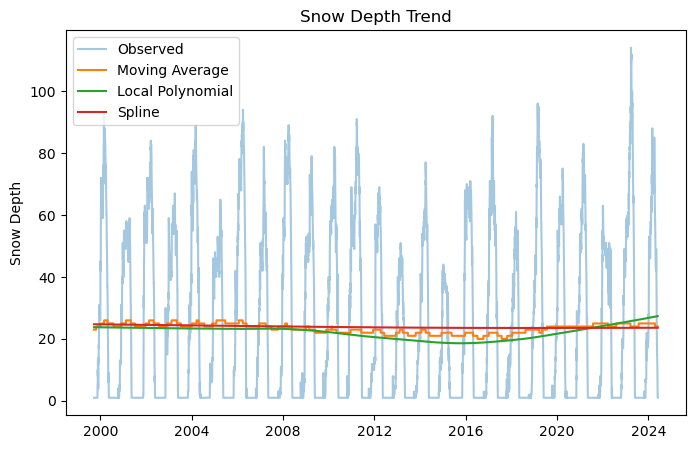

In [61]:
plt.figure(figsize = (8,5))
plt.plot(sd_train['ts'], alpha =.4)
plt.plot(sd_train['MovingAvg_Trend'])

plt.plot(sd_train['LocalPoly_Trend'])
plt.plot(sd_train['spline'])

plt.legend(['Observed', 'Moving Average', 'Local Polynomial', 'Spline'])
plt.ylabel('Snow Depth')
plt.title("Snow Depth Trend", size=12)
plt.show()

To determine any trend in the data, a moving average, local polynomial using LOWESS, and splines regression were all used.  The moving average appears to capture some of the seasonal pattern in the data.  The splines regression shows no discernable trend, while the local polynomial shows a slight decrease from 2012 to 2016, and then an increase from 2016 till 2024. As the local polynomial appears to best capture the long term fluctuations in the daily snow levels, it will be used in further decomposition models. 

## Seaonality Estimation

Two approaches are taken for estimating seasonality: seasonal means (ANOVA) for monthly, weekly, or daily variables, and harmonic or Fourier series seasonality.  With a year long seasonal cycle, and data at the daily level, seasonal means models will result in many categorical variables (52 if weekly is model, and more if daily). 

In [12]:
## Function to generate harmonic series for seaonality 
def generate_fourier_terms(time, period, K):

    fourier_terms = {}
    for k in range(1, K + 1):
        fourier_terms[f'sin_{k}'] = np.sin(2 * np.pi * k * time / period)
        fourier_terms[f'cos_{k}'] = np.cos(2 * np.pi * k * time / period)
    return pd.DataFrame(fourier_terms)


f_train = generate_fourier_terms(sd_train.index.dayofyear, 365, 3)
f_train =f_train.set_index(sd_train.index)
f_train


,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3
Date,,,,,,
1999-09-23,-0.991114,-0.133015,0.263665,-0.964614,0.920971,0.389630
1999-09-24,-0.993257,-0.115935,0.230306,-0.973118,0.939856,0.341571
1999-09-25,-0.995105,-0.098820,0.196673,-0.980469,0.956235,0.292600
1999-09-26,-0.996659,-0.081676,0.162807,-0.986658,0.970064,0.242850
1999-09-27,-0.997917,-0.064508,0.128748,-0.991677,0.981306,0.192452
...,...,...,...,...,...,...
2024-05-27,0.559589,-0.828770,-0.927542,0.373720,0.977848,0.209315
2024-05-28,0.545240,-0.838280,-0.914128,0.405426,0.987349,0.158559
2024-05-29,0.530730,-0.847541,-0.899631,0.436651,0.994218,0.107381


In [13]:
sd_train =sd_train.join(f_train)


Models are fit on the snow depth as well as the log transformation of snow depth, to see if the transformation will allow for accurate modeling of the zero snow depth during warm months. Harmonic models with 2 and 3 cycles are fit, as well as a model for weekly seasonal means. 

In [14]:


sd_train['ts_sqrt'] = np.sqrt(sd_train['ts'])
sd_train['ts_log'] = np.log(sd_train['ts'])

seasonalmodel_LocalPoly_trend_Harmonic2 = smf.ols(formula = 'ts~ sin_1 + cos_1+ +cos_2 +sin_2+ LocalPoly_Trend', data = sd_train).fit()
seasonalmodel_LocalPoly_trend_Harmonic3 = smf.ols(formula = 'ts~ sin_1 + cos_1+ +cos_2 +sin_2+ +cos_3 + sin_3+ LocalPoly_Trend', data = sd_train).fit()
seasonal_model_WeeklyAnova_w_Poly = smf.ols(formula = 'ts~C(week)+LocalPoly_Trend', data = sd_train).fit()

log_harmonic_2 = smf.ols(formula = 'ts_log~ sin_1 + cos_1+ +cos_2 +sin_2+ LocalPoly_Trend', data = sd_train).fit()
log_harmonic_3 = smf.ols(formula = 'ts_log~ sin_1 + cos_1+ +cos_2 +sin_2+ +cos_3 + sin_3+ LocalPoly_Trend', data = sd_train).fit()
log__weekly_anova =  smf.ols(formula = 'ts_log~C(week)+LocalPoly_Trend', data = sd_train).fit()

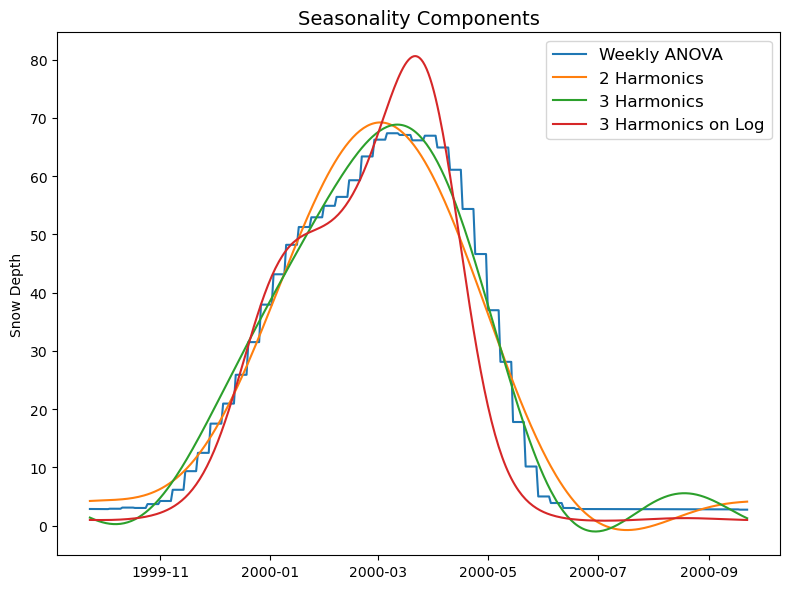

In [64]:
fig, axs = plt.subplots(1,1,figsize = (8,6))
plt.plot(seasonal_model_WeeklyAnova_w_Poly.fittedvalues[:365])
plt.plot(seasonalmodel_LocalPoly_trend_Harmonic2.fittedvalues[:365])
plt.plot(seasonalmodel_LocalPoly_trend_Harmonic3.fittedvalues[:365])
plt.plot(np.exp(log_harmonic_3.fittedvalues[:365]))
plt.title("Seasonality Components", size = 14)
plt.ylabel("Snow Depth")
plt.legend(['Weekly ANOVA', '2 Harmonics', '3 Harmonics', '3 Harmonics on Log'], fontsize = 12)
plt.tight_layout()


## Analyzing Fit

In [16]:
def analysis_plots(observed, fitted, residuals,  model_name):
    fig, axs = plt.subplots(4,1, figsize =(12,14) )
    axs[0].plot(observed, color = 'grey', alpha = .7)
    axs[0].plot(fitted, color = 'green')
    axs[0].set_ylabel("Snow Depth")
    axs[0].legend(['Observed', model_name], fontsize = 8)
    axs[0].set_title(model_name, size=10)

    axs[1].plot(residuals)
    axs[1].set_ylabel("Residuals")
    axs[1].set_title(f"{model_name} residuals", size = 10)

    plot_acf(residuals, ax=axs[2] ,lags= 350)
    plot_pacf(residuals, ax=axs[3], lags = 350 )
    axs[2].set_title(f"ACF: { model_name}", size = 9)
    axs[3].set_title(f"PACF: { model_name}", size = 9)
    fig.tight_layout()
    df_test = adfuller(residuals, regression = 'c')
    print(f"ADF: Test statistic = {df_test[0]:.4f}, p-value = {df_test[1]:.4f}")
    statistic, p_value, n_lags, critical_values = kpss(residuals, regression='c')
    print(f"Kpss: Test statistic = {statistic}, p-value = {p_value}")
    

### Harmonic Models

ADF: Test statistic = -10.5245, p-value = 0.0000
Kpss: Test statistic = 0.06310523325347155, p-value = 0.1


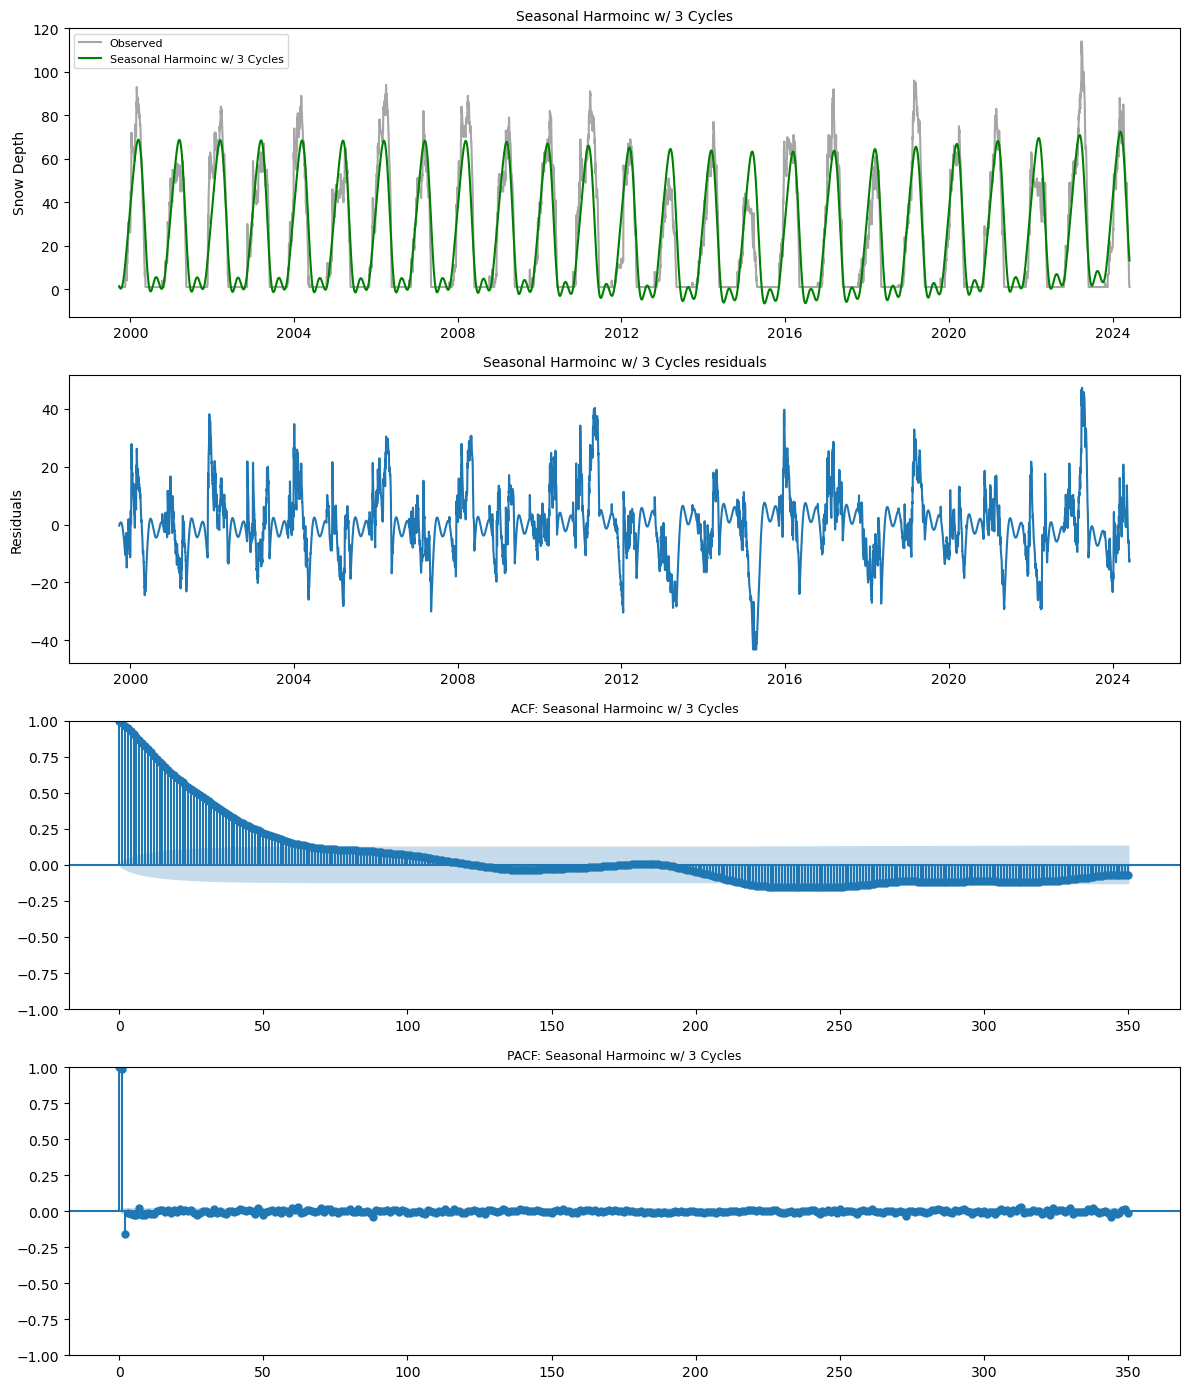

In [17]:
analysis_plots(sd_train['ts'], seasonalmodel_LocalPoly_trend_Harmonic3.fittedvalues, seasonalmodel_LocalPoly_trend_Harmonic3.resid, "Seasonal Harmoinc w/ 3 Cycles")

ADF: Test statistic = -14.6329, p-value = 0.0000
Kpss: Test statistic = 0.07431314716855086, p-value = 0.1


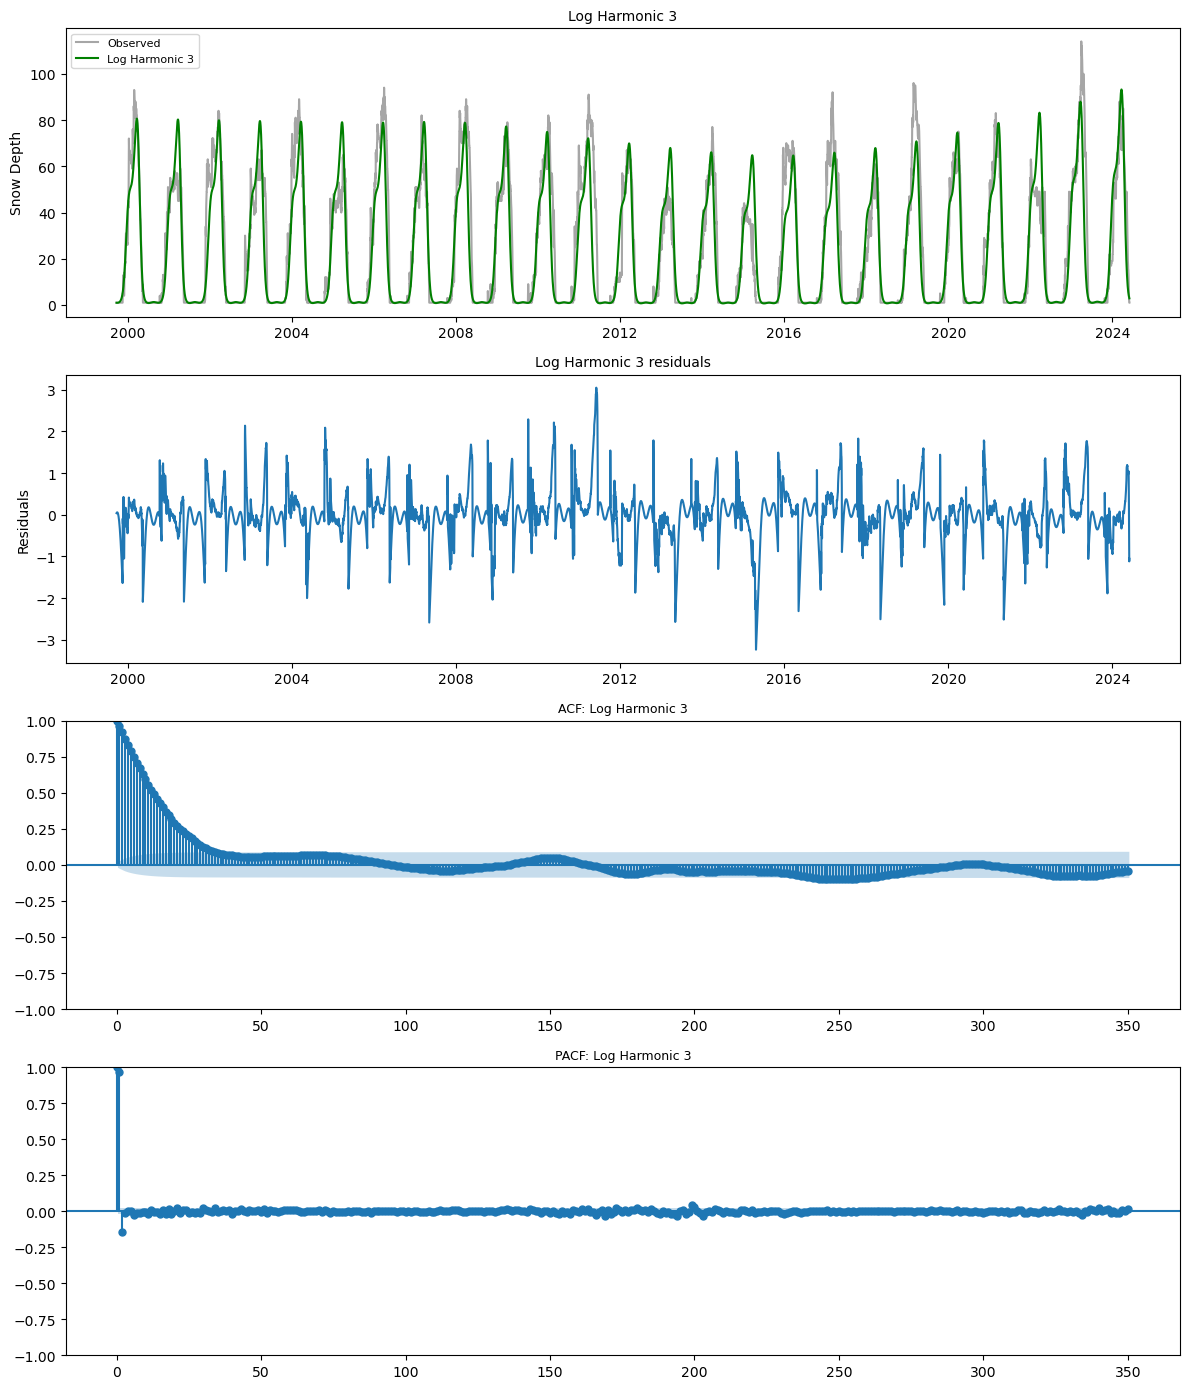

In [18]:
analysis_plots(sd_train['ts'], np.exp(log_harmonic_3.fittedvalues), log_harmonic_3.resid, "Log Harmonic 3")


ADF: Test statistic = -10.6852, p-value = 0.0000
Kpss: Test statistic = 0.05864095450290043, p-value = 0.1


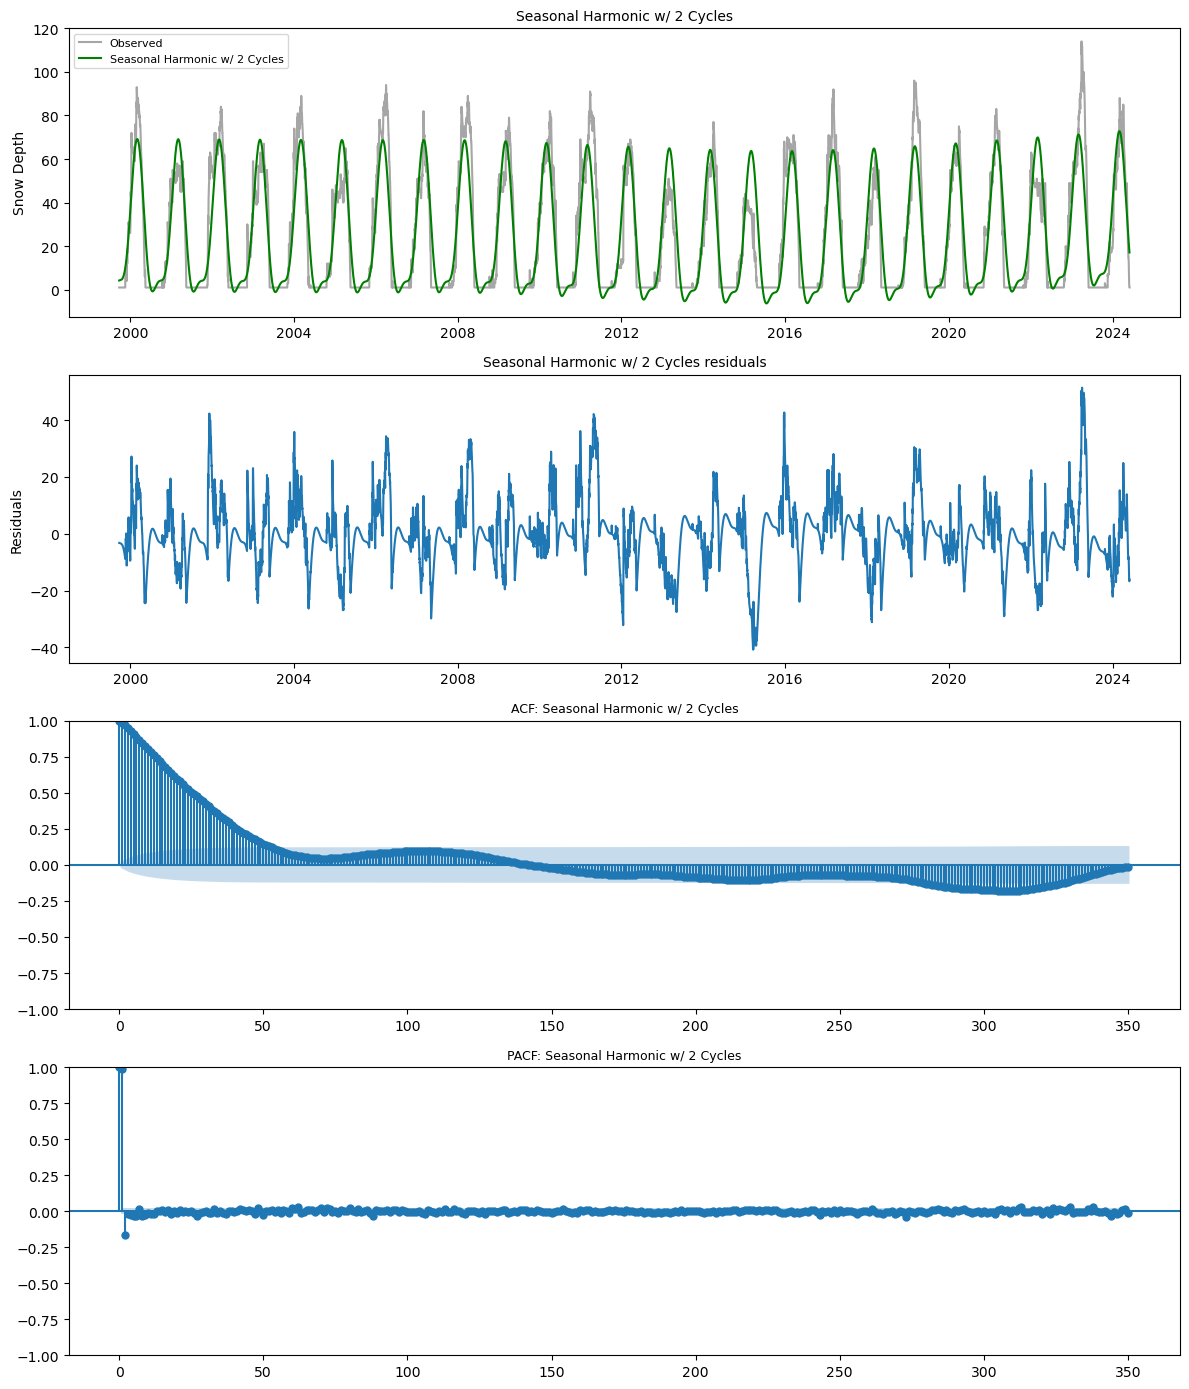

In [19]:
analysis_plots(sd_train['ts'], seasonalmodel_LocalPoly_trend_Harmonic2.fittedvalues, seasonalmodel_LocalPoly_trend_Harmonic2.resid, "Seasonal Harmonic w/ 2 Cycles")


### ANOVA

ADF: Test statistic = -9.1336, p-value = 0.0000
Kpss: Test statistic = 0.06342396047439072, p-value = 0.1


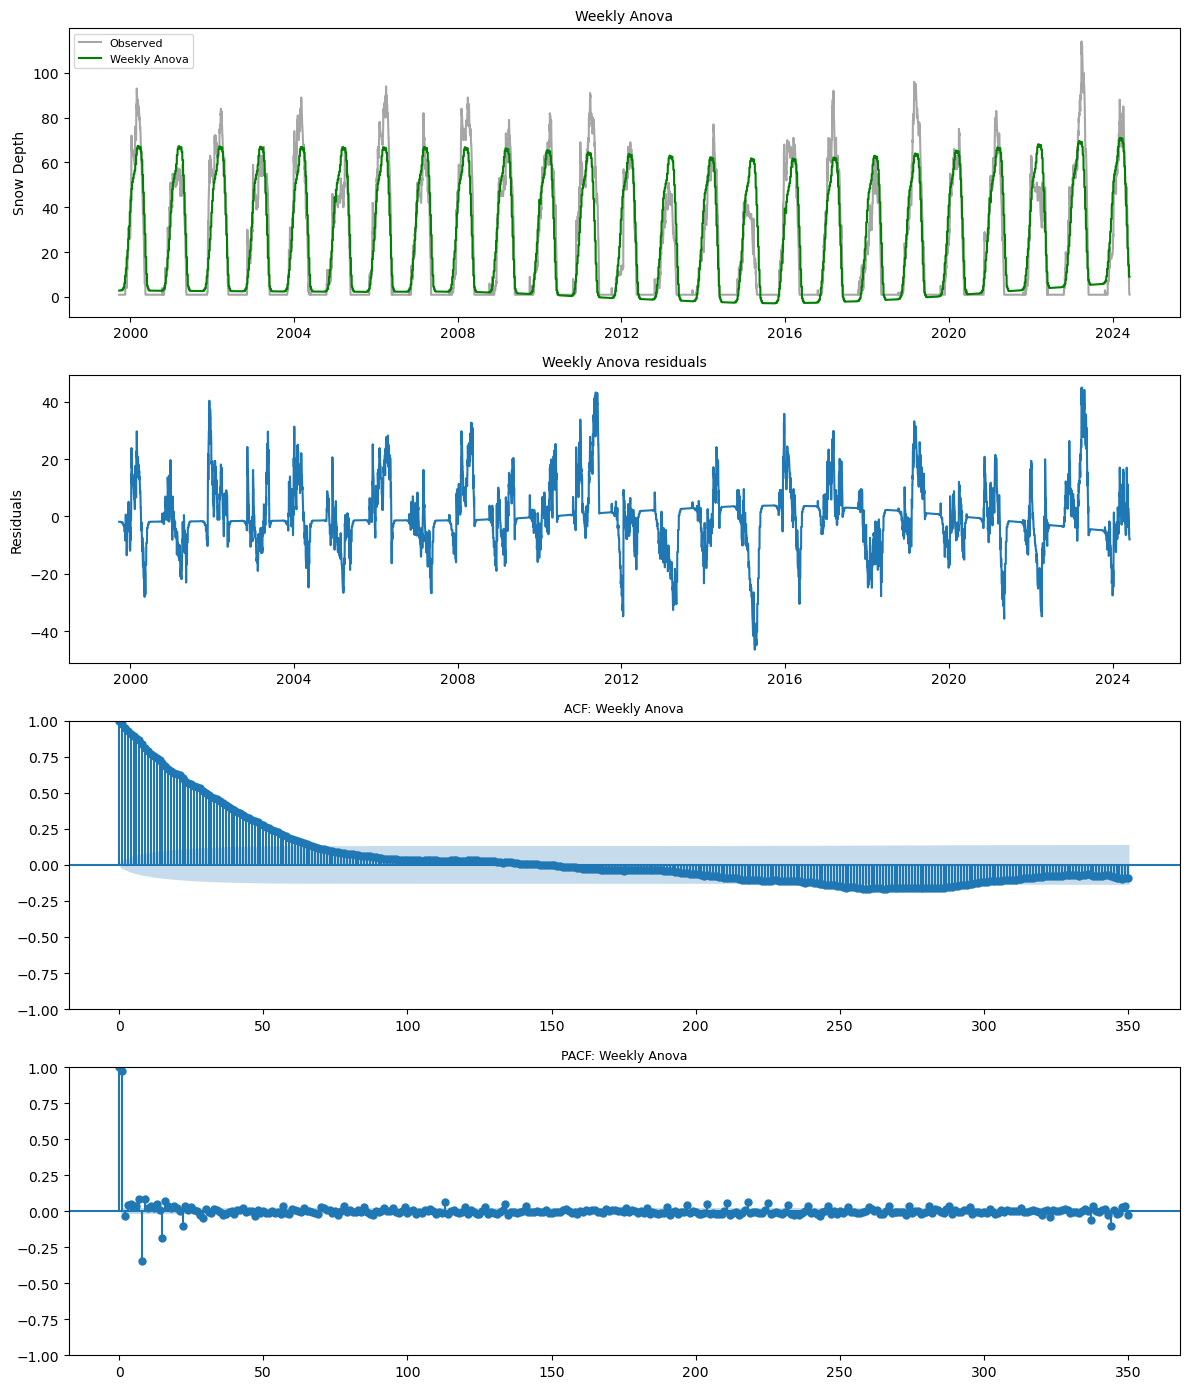

In [20]:
analysis_plots(sd_train['ts'], seasonal_model_WeeklyAnova_w_Poly.fittedvalues, seasonal_model_WeeklyAnova_w_Poly.resid, "Weekly Anova")


## Forecasting Aadditive Models

Prepping test data for forecasting

In [21]:
f_test = generate_fourier_terms(sd_test.index.dayofyear, 365, 3)
f_test = f_test.set_index(sd_test.index)
sd_test = sd_test.join(f_test)

Text(0.5, 1.0, 'Additive Models: Forecast')

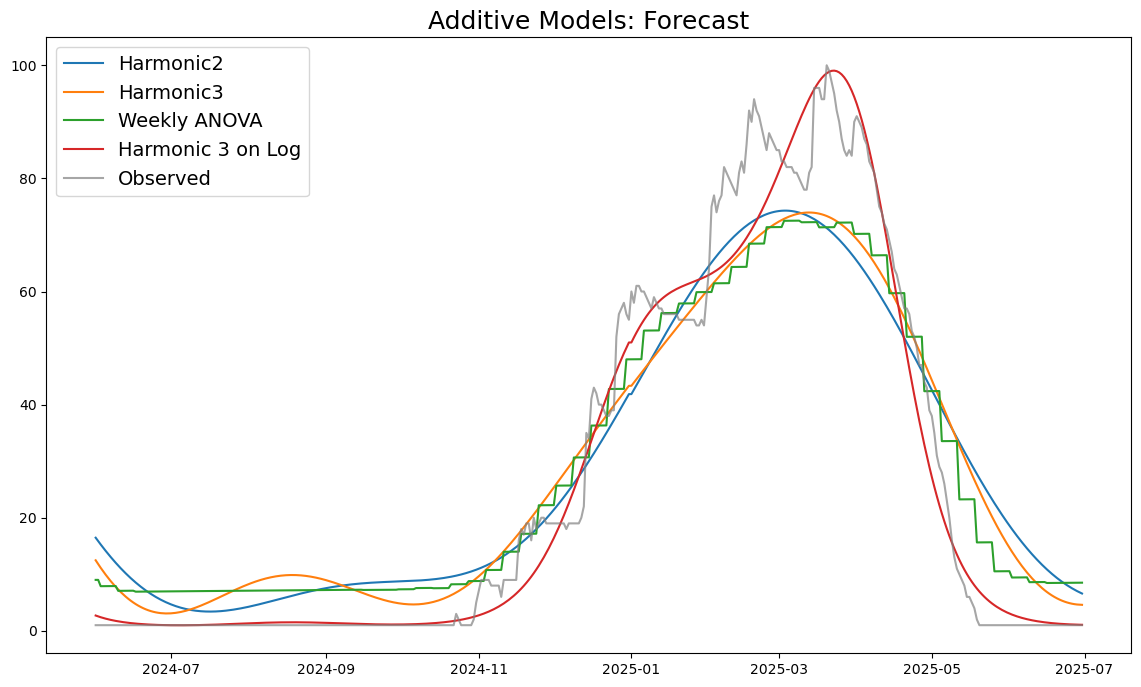

In [22]:

sd_test['ts_sqrt'] = np.sqrt(sd_test['ts'])
sd_test['ts_log'] = np.log(sd_test['ts']+1)



plt.figure( figsize = (14,8))
#plt.plot(seasonalmodel_LocalPoly_trend_myf.predict(exog = sd_test)**2)
plt.plot(seasonalmodel_LocalPoly_trend_Harmonic2.predict(exog = sd_test))
plt.plot(seasonalmodel_LocalPoly_trend_Harmonic3.predict(exog = sd_test))
#plt.plot(seasonalmodel_no_trend.predict(exog=sd_test)**2)
# plt.plot(seasonalmodel_LocalPoly_trend.predict(exog=sd_test)**2)
# plt.plot(seasonalmodel_MA_trend.predict(exog=sd_test)**2)
plt.plot(seasonal_model_WeeklyAnova_w_Poly.predict(exog=sd_test))
plt.plot(np.exp(log_harmonic_3.predict(exog=sd_test)))
# plt.plot(seasonal_model_DailyAnova_w_Poly.predict(exog=sd_test)**2)
plt.plot(sd_test['ts'], color = 'grey', alpha = .7)
plt.legend(['Harmonic2', 'Harmonic3', "Weekly ANOVA", 'Harmonic 3 on Log','Observed'], fontsize = 14)
plt.title("Additive Models: Forecast", size = 18)


All additive models follow the basic seasonal pattern of the last year of the data.  However, they fail to capture the nuance of the data, not following any increase after snow storms. All fail to effectivly capture the zero snow depth that occurs between late spring thru fall

In [23]:
evaluate_performance(sd_test['ts'],seasonalmodel_LocalPoly_trend_Harmonic2.predict(exog = sd_test), 'local poly harmonic 2' )
evaluate_performance(sd_test['ts'],seasonalmodel_LocalPoly_trend_Harmonic3.predict(exog = sd_test), 'local poly harmonic 3' )
evaluate_performance(sd_test['ts'],seasonal_model_WeeklyAnova_w_Poly.predict(exog = sd_test), 'weekly anova' )
evaluate_performance(sd_test['ts'], np.exp(log_harmonic_3.predict(exog=sd_test)), "log Harmonic")  



=== local poly harmonic 2 Performance ===
MSPE: 126.1570
MAE:  9.1929
MAPE: 4.0960
PM:   0.1152
----------------------------------------
=== local poly harmonic 3 Performance ===
MSPE: 109.1144
MAE:  8.4820
MAPE: 3.4732
PM:   0.0996
----------------------------------------
=== weekly anova Performance ===
MSPE: 95.0949
MAE:  8.1642
MAPE: 3.5230
PM:   0.0868
----------------------------------------
=== log Harmonic Performance ===
MSPE: 32.0314
MAE:  3.5622
MAPE: 0.4069
PM:   0.0292
----------------------------------------


## Facebook Prophet

Facebook prophet is a additive time-series forecasting model.  Its output will be compared to the additve modled developed above.

In [24]:
## Shaping data for prophet
prof_train = pd.DataFrame( sd_train.index, sd_train.copy()['ts_log']).reset_index()
prof_train.rename(columns={'ts_log':'y', 'Date':'ds'}, inplace=True)
prof_train.head()

prof_test = pd.DataFrame( sd_test.index, sd_test.copy()['ts_log']).reset_index()
prof_test.rename(columns={'ts_log':'y', 'Date':'ds'}, inplace=True)
prof_test.head()

,y,ds
0,0.693147,2024-06-01
1,0.693147,2024-06-02
2,0.693147,2024-06-03
3,0.693147,2024-06-04
4,0.693147,2024-06-05


15:06:08 - cmdstanpy - INFO - Chain [1] start processing
15:06:09 - cmdstanpy - INFO - Chain [1] done processing


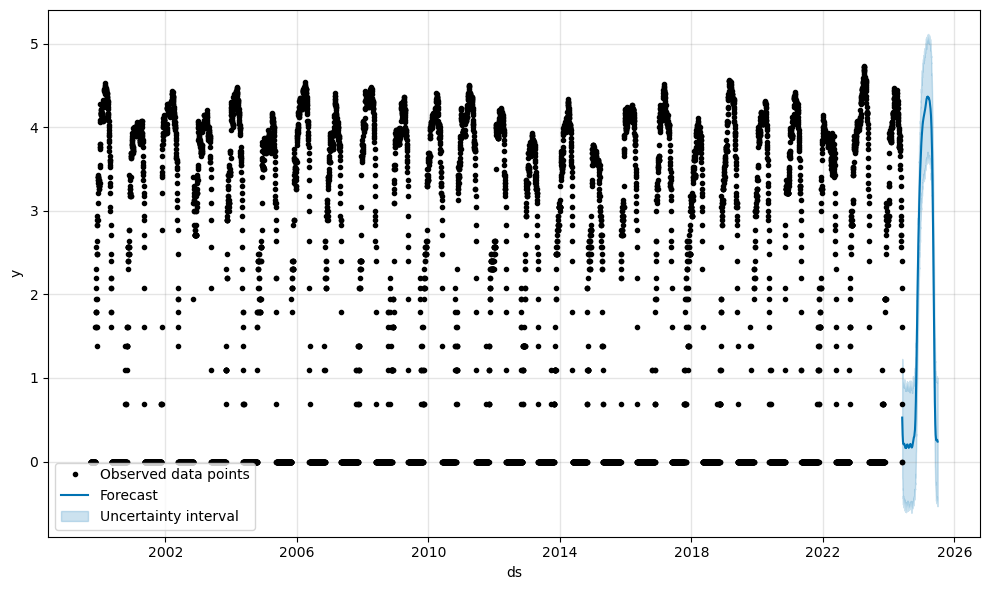

In [25]:
m = Prophet()
m.fit(prof_train)
prof_forecast = m.predict(prof_test)
plot = m.plot(prof_forecast, include_legend=True, )
plot.show()

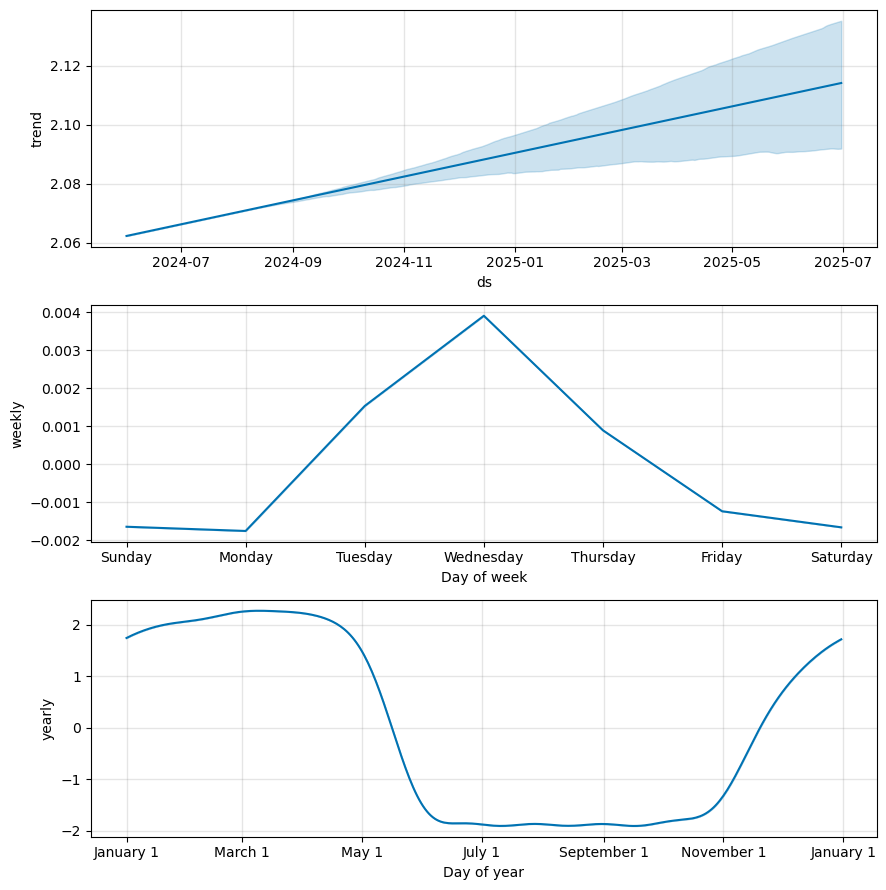

In [26]:
m.plot_components(prof_forecast);

The Prophet model components refelct a fairly linear increasing trend.  The weekly seasonality is on a scale so small that it is not significant.  The yearly seasonality does follow an expected cycle of increasing snow levels starting in the late fall thru the winter, with shaperer decreses as tempearture warms into the spring and summer. 

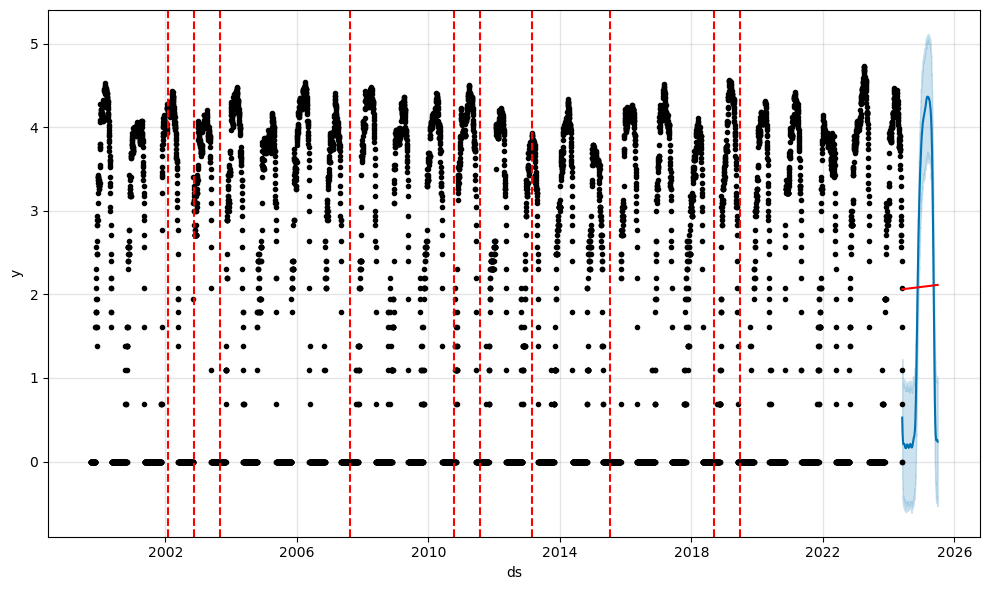

In [27]:
from prophet.plot import add_changepoints_to_plot
fig = m.plot(prof_forecast)
a = add_changepoints_to_plot(fig.gca(),
                             m, prof_forecast)

The Prophet model has identified several changepoints.

In [28]:
prof_forecast_vals = np.exp(prof_forecast['yhat'])
prof_forecast_vals.index = prof_forecast['ds']

Comparing the prophet forecast to the log_harmonic_3 forecast

Text(0.5, 1.0, 'Log Prophet and Log Harmonic')

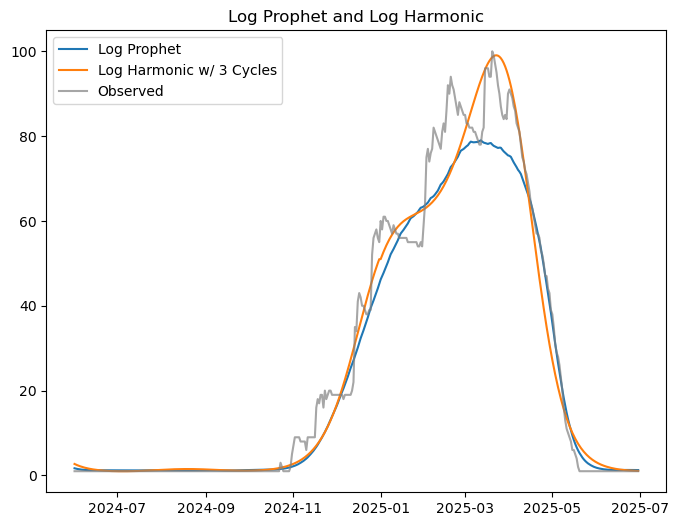

In [29]:
plt.figure(figsize = (8,6))
plt.plot(prof_forecast_vals)
plt.plot(np.exp(log_harmonic_3.predict(exog=sd_test)))
plt.plot(sd_test['ts'], color = 'grey', alpha = .7)
plt.legend(['Log Prophet', 'Log Harmonic w/ 3 Cycles', 'Observed'])
plt.title('Log Prophet and Log Harmonic')

Both the prophet model and the log harmonic model result in similar year-ahead forecasts, with both capturing the overall seasonal pattern well.  They reflect the steady increase of snow level caused by late fall and winter snow storms, and the rapid decrease in levels as temperatures warm.  Additionaly, the log transformation allows them to capture the zero snow levels in warm months. 

In [30]:
evaluate_performance(sd_test['ts'],prof_forecast_vals, 'profet')

=== profet Performance ===
MSPE: 39.2645
MAE:  3.7209
MAPE: 0.2949
PM:   0.0358
----------------------------------------


# ARIMA with Fourier Series

One of the characteristics of this snow depth data is the fact that there is strong autocorrelation among the observations: the snow depth today is directly related to the level of snow yesterday, and in the days prior. A model with autoregressive terms will be better suited to capture this behavior. 

However, there is still strong seasonality in this data, with an steady increase in snow levels from fall thru late winter, followed by a quick decrease in snow level as temperatures warm thru spring, and zero snow in warm summer months.  Combining the Fourier series with the ARIMA model should capture this behavior well.
 

### Preping data and generating harmonic seires

In [31]:
sd_train['ts_log'] = np.log(sd_train['ts'])

In [32]:
ArimaHarmonics = generate_fourier_terms(sd_train.index.dayofyear, 365, 3)
ArimaHarmonics.index = sd_train.index
ArimaHarmonics

,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3
Date,,,,,,
1999-09-23,-0.991114,-0.133015,0.263665,-0.964614,0.920971,0.389630
1999-09-24,-0.993257,-0.115935,0.230306,-0.973118,0.939856,0.341571
1999-09-25,-0.995105,-0.098820,0.196673,-0.980469,0.956235,0.292600
1999-09-26,-0.996659,-0.081676,0.162807,-0.986658,0.970064,0.242850
1999-09-27,-0.997917,-0.064508,0.128748,-0.991677,0.981306,0.192452
...,...,...,...,...,...,...
2024-05-27,0.559589,-0.828770,-0.927542,0.373720,0.977848,0.209315
2024-05-28,0.545240,-0.838280,-0.914128,0.405426,0.987349,0.158559
2024-05-29,0.530730,-0.847541,-0.899631,0.436651,0.994218,0.107381


## Arima Search

ARIMA fit on snow depth

In [33]:
maxp=7
maxd=2
maxq=7

best_bic = np.inf
selected_orders = (0,0,0)

for p in range(maxp+1):
    for q in range(maxq+1):
        for d in range(maxd):
            orders = (p,d,q)
            model = sm.tsa.statespace.SARIMAX(
                sd_train['ts'], 
                exog = ArimaHarmonics,
                order=orders                   
                        )

    results = model.fit()
    bic = results.bic
    if bic < best_bic:
        best_bic = bic
        selected_orders = orders

print(selected_orders, bic)

(0, 1, 7) 36356.47334590616


In [34]:
arima_fourier_model =sm.tsa.statespace.SARIMAX(
                sd_train['ts'], 
                exog = ArimaHarmonics,
                order=selected_orders ).fit()
print(arima_fourier_model.summary())


                               SARIMAX Results                                
Dep. Variable:                     ts   No. Observations:                 9016
Model:               SARIMAX(0, 1, 7)   Log Likelihood              -18086.640
Date:                Fri, 01 May 2026   AIC                          36201.280
Time:                        15:08:22   BIC                          36300.773
Sample:                             0   HQIC                         36235.132
                               - 9016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sin_1         27.9409      3.756      7.438      0.000      20.579      35.303
cos_1         17.8729      3.624      4.932      0.000      10.770      24.975
sin_2          8.4882      2.562      3.313      0.0

Arima fit on Log of snow depth

In [35]:
maxp=7
maxd=2
maxq=7

best_bic = np.inf
selected_orders = (0,0,0)

for p in range(maxp+1):
    for q in range(maxq+1):
        for d in range(maxd):
            orders = (p,d,q)
            model = sm.tsa.statespace.SARIMAX(
                sd_train['ts_log'], 
                exog = ArimaHarmonics,
                order=orders                   
                        )

    results = model.fit()
    bic = results.bic
    if bic < best_bic:
        best_bic = bic
        selected_orders = orders

print(selected_orders, bic)

(1, 1, 7) -7923.001050855033


In [36]:
log_arima_fourier_model =sm.tsa.statespace.SARIMAX(
                sd_train['ts_log'], 
                exog = ArimaHarmonics,
                order=selected_orders ).fit()
print(log_arima_fourier_model.summary())


                               SARIMAX Results                                
Dep. Variable:                 ts_log   No. Observations:                 9016
Model:               SARIMAX(1, 1, 7)   Log Likelihood                4062.069
Date:                Fri, 01 May 2026   AIC                          -8094.138
Time:                        15:12:22   BIC                          -7987.538
Sample:                             0   HQIC                         -8057.867
                               - 9016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sin_1          1.8058      0.187      9.659      0.000       1.439       2.172
cos_1          1.5689      0.119     13.131      0.000       1.335       1.803
sin_2          0.1796      0.065      2.756      0.0

## ARIMA Analysis

ADF: Test statistic = -95.7610, p-value = 0.0000
Kpss: Test statistic = 0.09616935515792832, p-value = 0.1


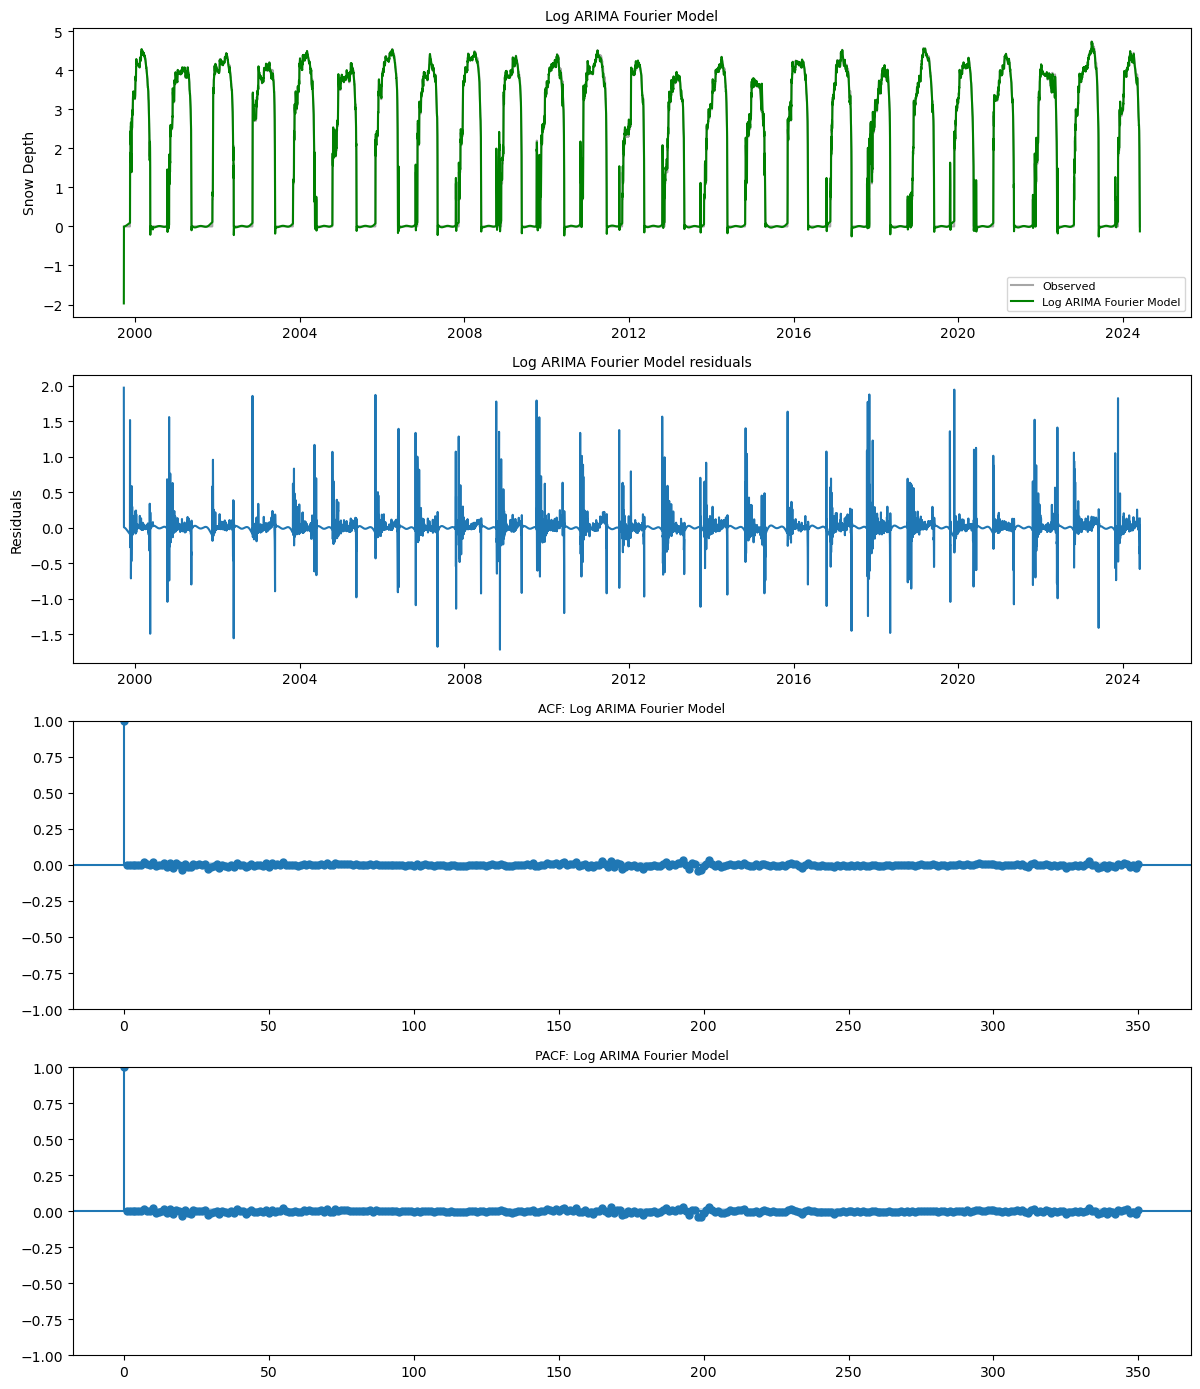

In [37]:
analysis_plots(sd_train['ts_log'], log_arima_fourier_model.fittedvalues, log_arima_fourier_model.resid, "Log ARIMA Fourier Model" )

ADF: Test statistic = -95.9361, p-value = 0.0000
Kpss: Test statistic = 0.01103962747545819, p-value = 0.1


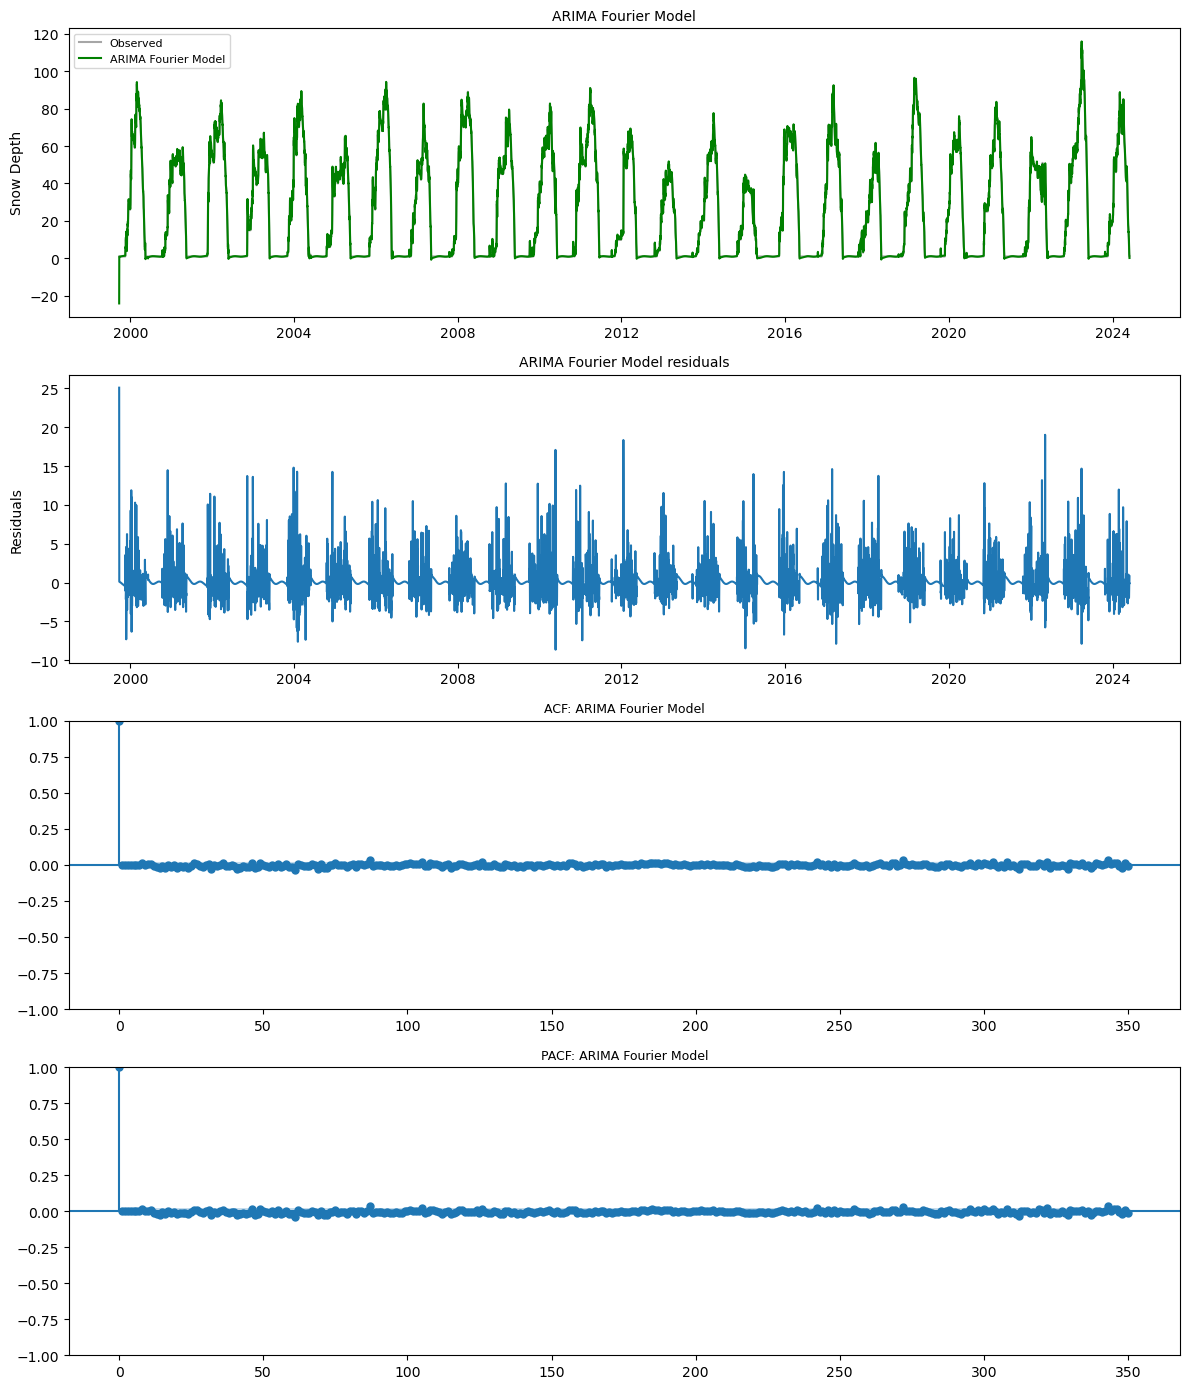

In [38]:
analysis_plots(sd_train['ts'],arima_fourier_model.fittedvalues, arima_fourier_model.resid, "ARIMA Fourier Model" )



The ARIMA Fourier models both appear to fit the data well. The inclusion of lag terms allow the model to react to shocks to the system that come in the form of snow storms.   The ACF and PACF plots inidcate possible weak stationarity; the results of the ADF and KPSS test also indicate possible weak stationarity.  However, there does appear to be a cyclical pattern remaining in the residuals caused by the zero snow depth values durring the warmer months 

## ARIMA Forecast

In [39]:


forecast_harmonics = generate_fourier_terms(sd_test.index.dayofyear, 365, 3)
forecast_harmonics.index = sd_test.index


In [40]:
arima_yr_forecast = arima_fourier_model.forecast(steps = 395, exog = forecast_harmonics)
log_arima_yr_forecast = log_arima_fourier_model.forecast(steps = 395, exog = forecast_harmonics)

### Year long forecast

Comparing the Log v Non-log ARIMA fourier forecasts for a one-year period.  The Log model appers to fit the data closer than the non-log.  

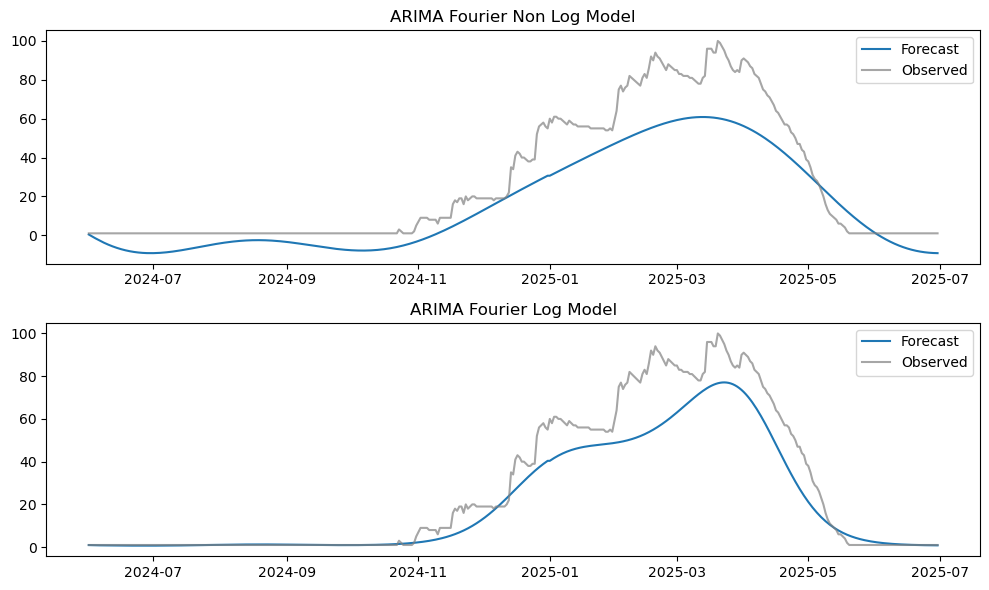

In [41]:
fig, axs = plt.subplots(2,1, figsize = (10,6))
axs[0].plot( sd_test.index, arima_yr_forecast )
axs[0].plot(sd_test['ts'], color = 'gray', alpha = .7)
axs[0].set_title('ARIMA Fourier Non Log Model')
axs[0].legend(["Forecast", "Observed"])

axs[1].plot(sd_test.index, np.exp(log_arima_yr_forecast ))
axs[1].plot(sd_test['ts'], color = 'gray', alpha = .7)
axs[1].set_title('ARIMA Fourier Log Model')
axs[1].legend(['Forecast', 'Observed'])
fig.tight_layout()



In [42]:
arima_yr_forecast.index =sd_test.index
arima_yr_forecast
log_arima_yr_forecast.index = sd_test.index

In [43]:
evaluate_performance(sd_test['ts'], arima_yr_forecast, 'Arima' )

=== Arima Performance ===
MSPE: 241.6945
MAE:  12.4041
MAPE: 3.4599
PM:   0.2207
----------------------------------------


In [44]:
evaluate_performance(sd_test['ts'], np.exp(log_arima_yr_forecast), 'ARIMA on Log Transformation')

=== ARIMA on Log Transformation Performance ===
MSPE: 129.1628
MAE:  7.0091
MAPE: 0.3358
PM:   0.1179
----------------------------------------


In [45]:
sd_train_roll = sd_train.copy()


### Rolling Forecast

Projecting all 395 points into the future leads to a forecast that follows the basic trend of the seaonal pattern observed, but does not leverage the lagged cooeficents fully.  Performing a rolling forecast, much more like in real life leverages these coeefecents much more and leads to much higher accuracy in the forecast. 

In [46]:
forecast_period = 7
number_of_runs = len(sd_test)//forecast_period
results = []
for r in range(1,number_of_runs):
    if r == 1:
        train_rolling = sd_train.copy()
        test_rolling = sd_test.copy()[:forecast_period]
    else: 
        train_rolling = pd.concat([train_rolling, test_rolling])
        test_rolling = sd_test.copy()[forecast_period*(r-1):forecast_period*r]
    f_train = train_rolling[['sin_1', 'cos_1', 'sin_2', 'cos_2', 'cos_3', 'sin_3']]
    f_test = test_rolling[['sin_1', 'cos_1', 'sin_2', 'cos_2','cos_3', 'sin_3']]
    
    if len(test_rolling) == forecast_period:  forecast_period = forecast_period
    else: forecast_period = len(test_rolling)
    model = sm.tsa.statespace.SARIMAX(
                train_rolling['ts'], 
                exog = f_train,
                order=selected_orders ).fit()
    forecast = model.forecast(steps = forecast_period, exog = f_test)
    forecast = forecast.set_axis(test_rolling.index)
     
    results.append(forecast)
full_forecast = pd.concat(results)




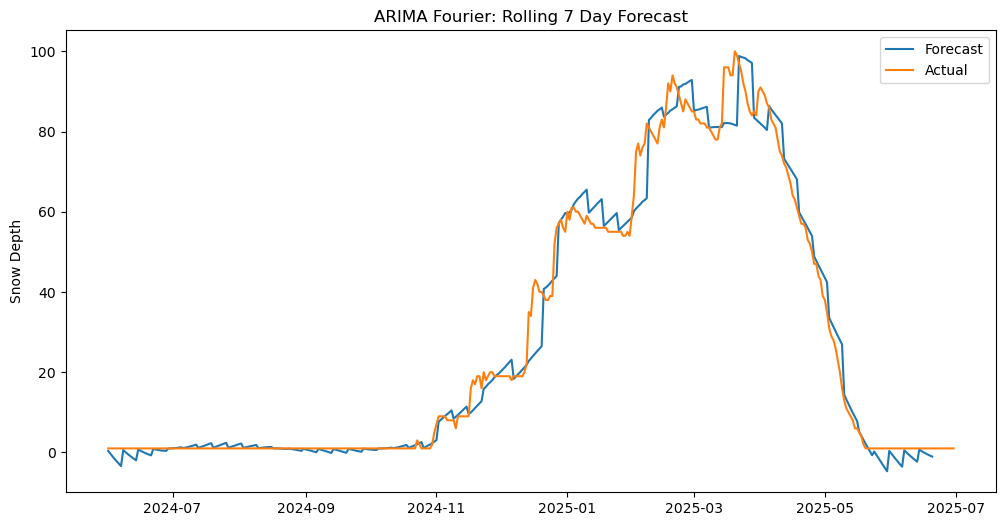

In [47]:


plt.figure(figsize = (12,6))
plt.plot(full_forecast)
plt.plot(sd_test['ts'])
plt.title("ARIMA Fourier: Rolling 7 Day Forecast")
plt.legend(['Forecast', 'Actual'])
plt.ylabel('Snow Depth')
plt.show()

In [48]:
evaluate_performance(sd_test['ts'][:385], full_forecast, "arima 7 day rolling")

=== arima 7 day rolling Performance ===
MSPE: 21.6208
MAE:  2.8387
MAPE: 0.4836
PM:   0.0196
----------------------------------------


Rolling 7 day forcast on log of snow depth


In [49]:
sd_test['ts_log'] = np.log(sd_test['ts'])

In [50]:
forecast_period = 7
number_of_runs = len(sd_test)//forecast_period
log_results = []
for r in range(1,number_of_runs):
    if r == 1:
        train_rolling = sd_train.copy()
        test_rolling = sd_test.copy()[:forecast_period]
    else: 
        train_rolling = pd.concat([train_rolling, test_rolling])
        test_rolling = sd_test.copy()[forecast_period*(r-1):forecast_period*r]
    f_train = train_rolling[['sin_1', 'cos_1', 'sin_2', 'cos_2','cos_3', 'sin_3']]
    f_test = test_rolling[['sin_1', 'cos_1', 'sin_2', 'cos_2','cos_3', 'sin_3']]
    
    if len(test_rolling) == forecast_period:  forecast_period = forecast_period
    else: forecast_period = len(test_rolling)
    model = sm.tsa.statespace.SARIMAX(
                train_rolling['ts_log'], 
                exog = f_train,
                order=selected_orders ).fit()
    forecast = model.forecast(steps = forecast_period, exog = f_test)
    forecast = forecast.set_axis(test_rolling.index)
     
    log_results.append(forecast)
log_full_forecast = pd.concat(log_results)

In [51]:
log_full_forecast = pd.concat(log_results)

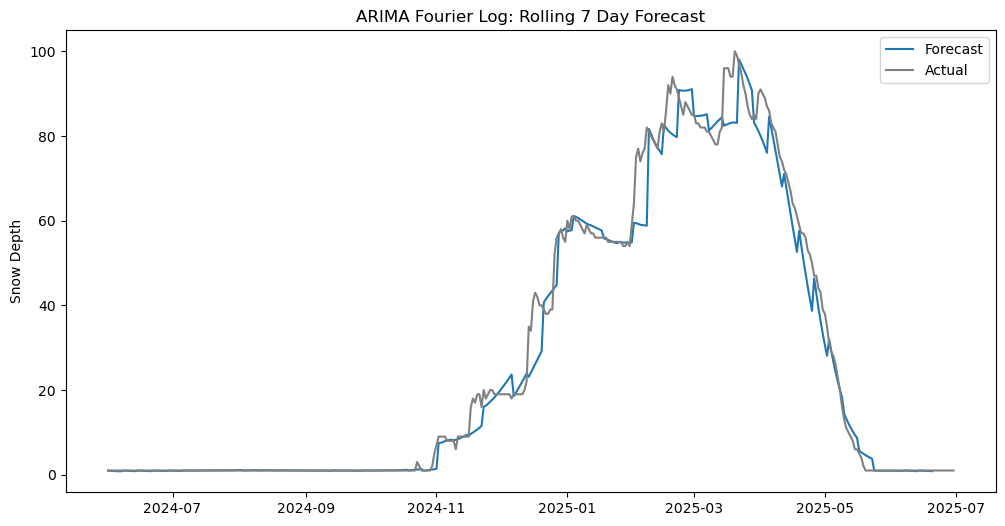

In [52]:
plt.figure(figsize = (12,6))
plt.plot(np.exp(log_full_forecast))
plt.plot(sd_test['ts'], color = 'grey')
plt.title("ARIMA Fourier Log: Rolling 7 Day Forecast")
plt.legend(['Forecast', 'Actual'])
plt.ylabel('Snow Depth')
plt.show()

In [53]:
evaluate_performance(sd_test['ts'][:385], np.exp(log_full_forecast), 'log arima rolling')

=== log arima rolling Performance ===
MSPE: 21.3279
MAE:  2.3687
MAPE: 0.1225
PM:   0.0193
----------------------------------------


# Final Comparisons

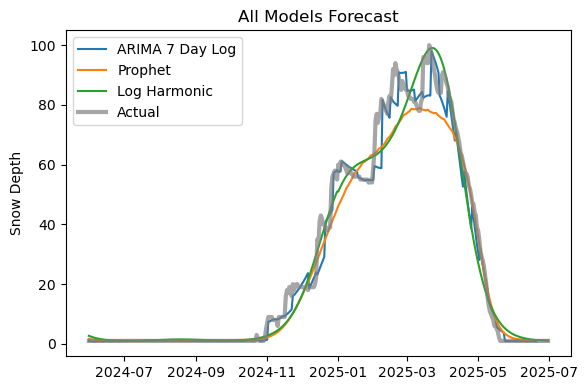

In [54]:
plt.figure(figsize = (6,4))
plt.plot(np.exp(log_full_forecast))
#plt.plot(full_forecast)
plt.plot(prof_forecast_vals)
plt.plot(np.exp(log_harmonic_3.predict(exog=sd_test)))
plt.plot(sd_test['ts'], color = 'grey', alpha = .7, linewidth = 3)
plt.title("All Models Forecast")
plt.legend(['ARIMA 7 Day Log' ,'Prophet', 'Log Harmonic', 'Actual'])

plt.ylabel('Snow Depth')
plt.tight_layout()
plt.show()

In [55]:
perf_df = pd.DataFrame(perf_results)


Comparing final three models forecast, the Log ARIMA rolling forcast appers to fit the data the best, and is reflected in its strong accuracy scores

In [56]:
perf_df[(perf_df["model"] == 'profet') |(perf_df["model"] == 'log Harmonic' )| (perf_df["model"] == 'log arima rolling')]

,model,MSPE,MAE,MAPE,PM
3,log Harmonic,32.031401,3.562248,0.406901,0.029243
4,profet,39.264497,3.720861,0.294862,0.035847
8,log arima rolling,21.327925,2.368668,0.122465,0.019292


## Plots for display

plots below are formatted to display cleaner in the final paper

In [57]:
def plots_for_paper(observed, fitted, residuals,  model_name):

    fig = plt.figure(constrained_layout=True)
    axs = fig.subplot_mosaic([['Top', 'Top'],['Mid', 'Mid'] ,['BottomLeft', 'BottomRight']])
    
    # axs['Mid'].set_title('Resid')
    # axs['BottomRight'].set_title('ACF')
    # axs['BottomLeft'].set_title('PACF')

    axs['Top'].set_title(model_name, fontsize = 11)
    axs['Top'].plot(fitted, color = 'red')
    axs['Top'].plot(observed, color = 'black', alpha = .5)
    
    axs['Top'].set_ylabel("Snow Depth")
    axs['Top'].legend([ model_name, "Observed"], fontsize = 10, loc = 'upper left')

    axs['Mid'].plot(residuals)
    axs['Mid'].set_ylabel("Residuals")
    axs['Mid'].set_title(f"{model_name} residuals", size = 10)

    plot_acf(residuals, ax=axs['BottomLeft'] ,lags= 350)
    plot_pacf(residuals, ax=axs['BottomRight'], lags = 350 )
    axs['BottomLeft'].set_title(f"ACF: { model_name}", size = 9)
    axs['BottomRight'].set_title(f"PACF: { model_name}", size = 9)
    
    fig.tight_layout()
    # df_test = adfuller(residuals, regression = 'c')
    # print(f"ADF: Test statistic = {df_test[0]:.4f}, p-value = {df_test[1]:.4f}")
    # statistic, p_value, n_lags, critical_values = kpss(residuals, regression='c')
    # print(f"Kpss: Test statistic = {statistic}, p-value = {p_value}")
    

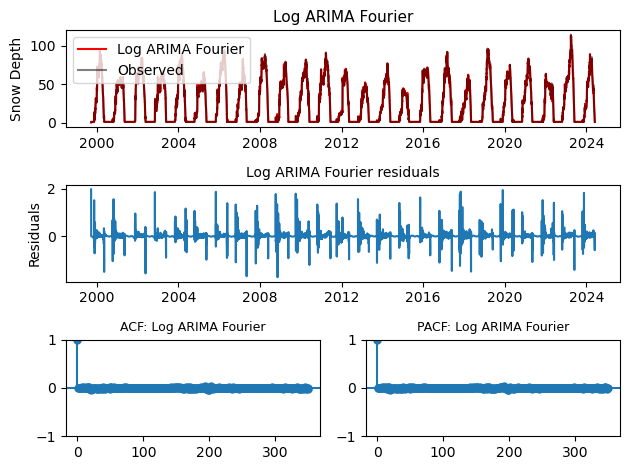

In [58]:
plots_for_paper(sd_train['ts'], np.exp(log_arima_fourier_model.fittedvalues), log_arima_fourier_model.resid, 'Log ARIMA Fourier')

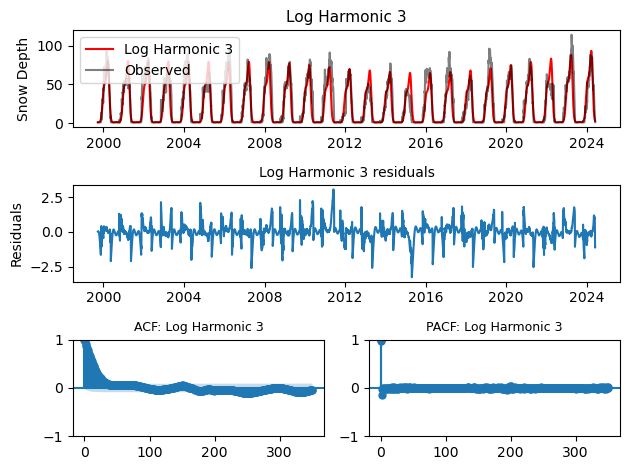

In [59]:
plots_for_paper(sd_train['ts'], np.exp(log_harmonic_3.fittedvalues), log_harmonic_3.resid, 'Log Harmonic 3')